# Segmentação de Clientes com K-means

Projeto de Ciência de Dados aplicando clustering (K-means) para segmentar clientes de um 
shopping center com base em idade, renda anual, comportamento de consumo (spending score) 
e gênero.

**Dataset:** Mall Customer Segmentation Data (Kaggle)

**Pergunta de negócio:** É possível identificar grupos distintos de clientes que ajudem a 
direcionar estratégias de marketing e fidelização?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.express as px

In [5]:
df = pd.read_csv("../archive/dados.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 1. Análise Exploratória de Dados (EDA)

In [6]:

#Veja as primeiras linhas do dataset
#Descubra quantas linhas e colunas existem
#Identifique o tipo de cada coluna (numérica, categórica, texto)
#Verifica a quantidade linhas head(numero de linhas a verificar)



# Verificando o numero de colunas e linhas
linhas = df.shape[0]
colunas = df.shape[1]

#print("Linhas:", linhas)
#print("Colunas:", colunas)

# Verificando o tipo de cada coluna

#print(df.dtypes)


#Verificando os informações das colunas e tabelas do DataFrame
print(df.info())



<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None


### 1.1 Qualidade dos dados
Verificação de valores nulos e duplicatas.

In [7]:
# Verificando a qualidade dos dados

df.isnull().sum() #Veriica se a valores nulos na coluna

v_duplicata = df.duplicated().sum() # Verifica a quantidade de valores duplicados

#df.duplicated() #Verifica se a linha anterior é uma duplicata. 

if v_duplicata >= 1:
    print(f"DataFrame com {v_duplicata} valores duplicados.")
    df_new = df.drop_duplicates()
    df = df_new
else:
    print("DataFrame limpo")


DataFrame limpo


### 1.2 Estatística Descritiva

In [8]:
#Estatistica Descritiva


def estatistica(parametros):
    media = parametros.mean()
    mediana = parametros.median()
    desvioPadrao = parametros.std()
    maximo = parametros.max()
    minimo = parametros.min()

    return media, mediana, desvioPadrao, maximo, minimo

media_Idade, mediana_Idade, desvioPadrao_Idade, maximo_Idade, minimo_Idade = estatistica(df['Age'])
media_KS, mediana_KS, desvioPadrao_KS, maximo_KS, minimo_KS = estatistica(df['Annual Income (k$)'])
media_score, mediana_score, desvioPadrao_score, maximo_score, minimo_score = estatistica(df['Spending Score (1-100)'])

female = df['Gender'].value_counts(normalize=True) * 100

print(f'Estatistica da idade: \nMedia: {media_Idade}\nMediana: {mediana_Idade}\nDesvio Padrão: {desvioPadrao_Idade}\nMaximo: {maximo_Idade}\nMinimo: {minimo_Idade}')

print(F'Estatistica Annual Income: \nMedia: {media_KS}\nMediana: {mediana_KS}\nDesvio Padrão: {desvioPadrao_KS}\nMaximo: {maximo_KS}\nMinimo: {minimo_KS}')

Estatistica da idade: 
Media: 38.85
Mediana: 36.0
Desvio Padrão: 13.96900733155888
Maximo: 70
Minimo: 18
Estatistica Annual Income: 
Media: 60.56
Mediana: 61.5
Desvio Padrão: 26.264721165271244
Maximo: 137
Minimo: 15


### 1.3 Distribuições das variáveis

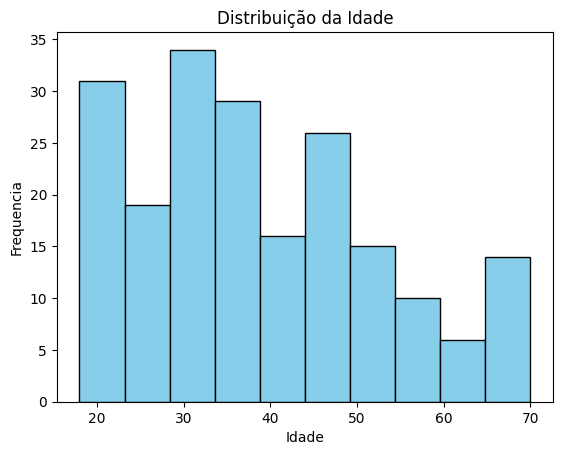

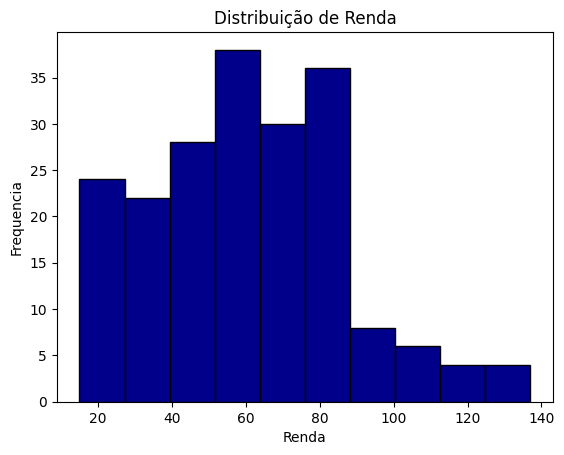

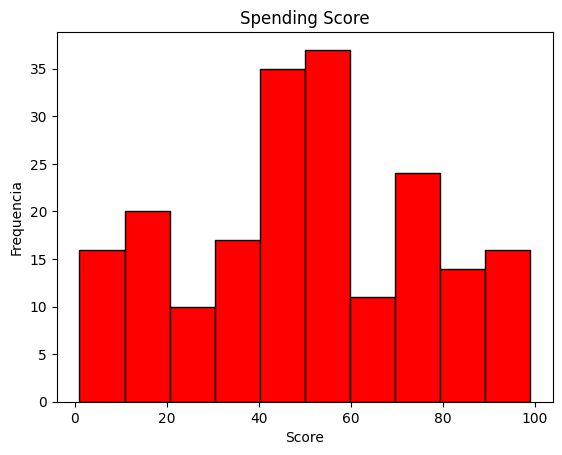

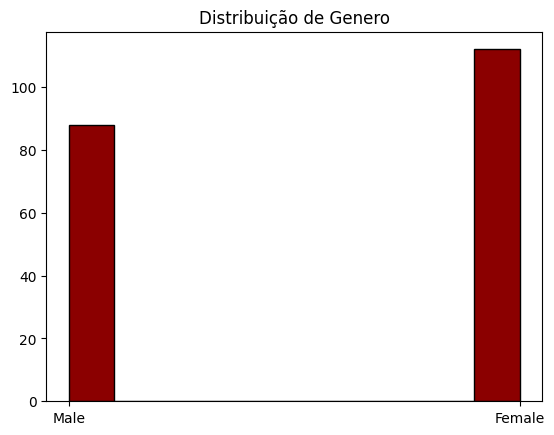

In [ ]:


plt.hist(df['Age'],
        color='skyblue',
        edgecolor='black')
plt.title("Distribuição da Idade")
plt.ylabel("Frequencia")
plt.xlabel("Idade")
plt.show()


plt.hist(df['Annual Income (k$)'],
        color='darkblue',
        edgecolor='black')
plt.title("Distribuição de Renda")
plt.ylabel("Frequencia")
plt.xlabel("Renda")
plt.show()

plt.hist(df['Spending Score (1-100)'],
        color='red',
        edgecolor='black')
plt.title('Spending Score')
plt.ylabel('Frequencia')
plt.xlabel("Score")
plt.show()

plt.hist(df['Gender'],
        color='DarkRed',
        edgecolor='black')
plt.title("Distribuição de Genero")
plt.show()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


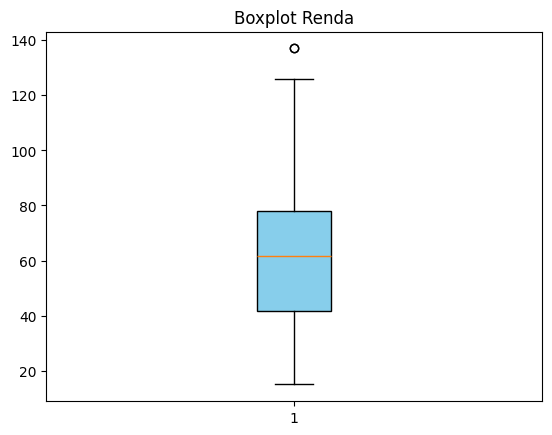

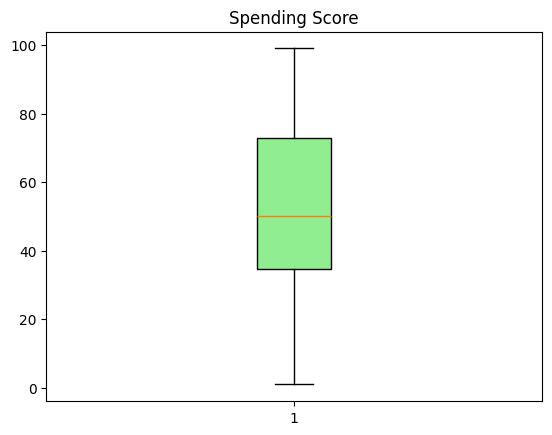

In [10]:
#Criando Boxplot

df.info()


plt.boxplot(
    df['Annual Income (k$)'].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor='skyblue')
)
plt.title("Boxplot Renda")
plt.show()

plt.boxplot(
    df['Spending Score (1-100)'].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen')
)
plt.title("Spending Score")
plt.show()

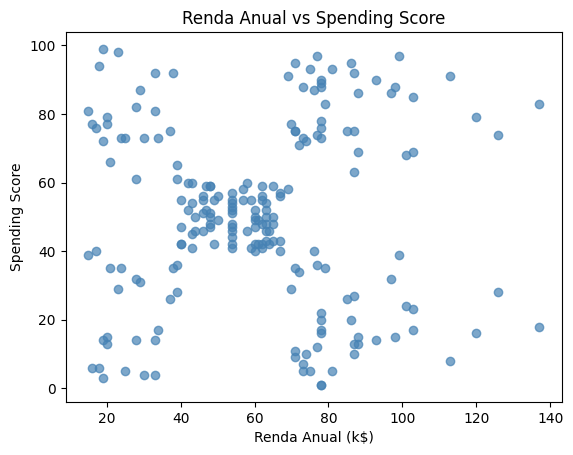

In [11]:
#Grafico de Dispersão

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    color='steelblue',
    alpha=0.7
)

plt.title("Renda Anual vs Spending Score")
plt.xlabel("Renda Anual (k$)")
plt.ylabel("Spending Score")

plt.show()

### 1.4 Correlação entre variáveis

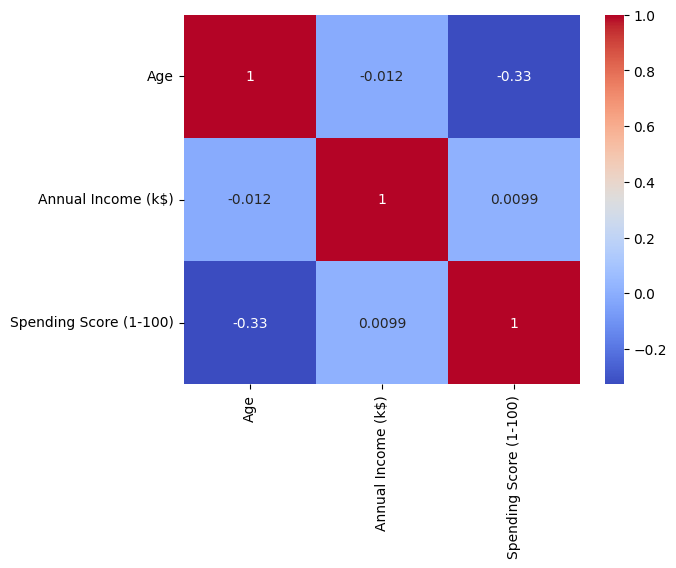

In [12]:
#Matriz Correlação 



sns.heatmap(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

## 2. Preparação dos Dados
Codificação da variável Gênero e padronização (Z-score) das variáveis numéricas antes 
do treinamento do modelo.

In [13]:
#Machine learning 



df_normalize = df.drop(columns='CustomerID') # Retirando a coluna que contem somente string

le = LabelEncoder() # Criando uma variavel responsavel por tornar string em numero entre 0 e 1.

df_normalize['Gender'] = le.fit_transform(df_normalize['Gender']) # Como gender tem somente duas carateristica, female e male, vamo transformar essa coluna em numero em binaria.

df_normalize.head(5)

Z = df_normalize[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']] # Normalizando todas as variaveis em Z, 

scaler = StandardScaler() # variavel responsavel por padronizar as nossas variaveis em Z 
Z_scaler = scaler.fit_transform(Z) # Árray com os dados padronizados em Z

le.classes_



array(['Female', 'Male'], dtype=object)

## 3. Escolha do Número de Clusters (Método do Cotovelo)

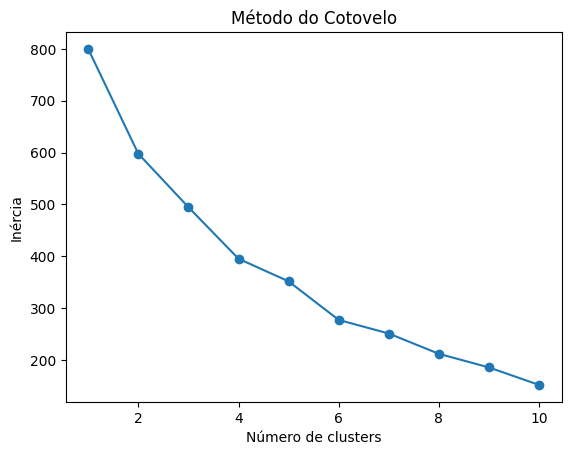

In [14]:
k = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42) # Criando uma variavel kmeans onde ela vai gerar os clusters.
    kmeans.fit(Z_scaler) # Treinando o modelo 
    k.append(kmeans.inertia_) # Adicionando os valores obtidos dentro de um array.

plt.plot(range(1, 11), k, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
plt.show()

## 4. Treinamento do Modelo Final (K=5)

In [15]:
# Testando o modelo final

kmeans_final = KMeans(n_clusters=5, random_state=42)
label = kmeans_final.fit_predict(Z_scaler)  

print(label) # cada elemento dentro do array, indica qual cluster o dado foi atribuido.

df['cluster'] = label



# Média de cada variável, por cluster
resumo = df.drop(columns='CustomerID').groupby('cluster').mean(numeric_only=True)
print(resumo)


[2 2 4 4 4 4 4 4 0 4 0 4 0 4 0 2 4 2 0 4 2 2 0 2 0 2 0 2 4 4 0 4 0 2 0 4 0
 4 4 4 0 2 0 4 0 4 0 4 4 4 0 2 4 0 0 0 0 0 4 0 0 2 0 0 0 2 4 0 2 4 0 0 0 0
 0 2 3 2 4 0 0 2 0 3 4 0 0 4 4 0 0 2 0 3 4 2 3 4 0 2 4 3 0 2 0 4 0 0 0 0 0
 4 3 2 4 4 0 3 3 3 2 3 3 2 3 3 1 2 1 2 1 2 3 3 1 3 3 2 1 3 0 2 3 3 1 2 1 3
 3 2 1 2 3 3 3 3 1 3 1 3 3 3 1 3 1 3 1 3 3 2 1 2 1 2 3 3 1 2 1 2 3 3 1 3 3
 2 3 2 3 3 3 3 1 3 3 3 3 2 1 2]
               Age  Annual Income (k$)  Spending Score (1-100)
cluster                                                       
0        56.470588           46.098039               39.313725
1        39.500000           85.150000               14.050000
2        28.690476           60.904762               70.238095
3        37.897959           82.122449               54.448980
4        27.315789           38.842105               56.210526


## 5. Visualização dos Clusters

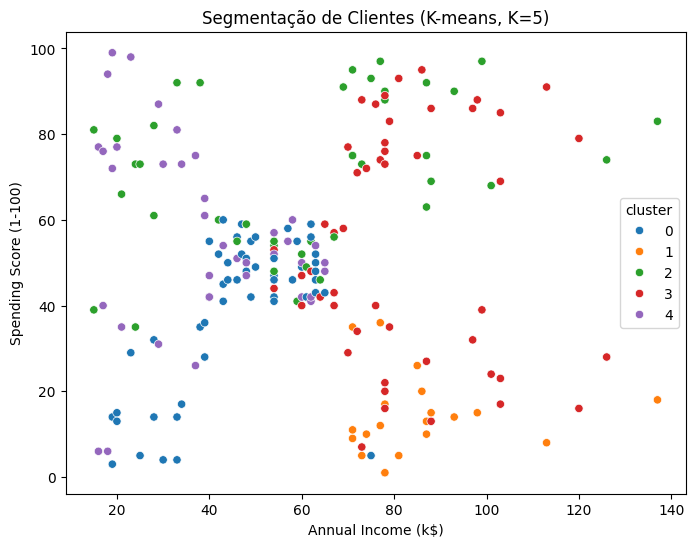

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='cluster', 
    palette='tab10',   # paleta com cores bem distintas entre si
    data=df
)
plt.title("Segmentação de Clientes (K-means, K=5)")
plt.show()

In [18]:


fig = px.scatter_3d(
    df, 
    x='Age', 
    y='Annual Income (k$)', 
    z='Spending Score (1-100)', 
    color='cluster',
    title="Segmentação de Clientes em 3D"
)
fig.show()

fig = px.scatter_3d(
    df, 
    x='Age', 
    y='Annual Income (k$)', 
    z='Spending Score (1-100)', 
    color='cluster',
    title="Segmentação de Clientes em 3D"
)
fig.show()

In [19]:

perfis = {
    0: "Cliente Maduro - Consumo Moderado",
    1: "Renda Alta - Baixo Engajamento",
    2: "Jovem - Alto Consumo",
    3: "Renda Alta - Bom Consumidor",
    4: "Jovem - Renda Baixa - Consumo Relativo Alto"
}

df_classificado = df.copy()
df_classificado['Perfil'] = df_classificado['cluster'].map(perfis)

df_classificado.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster,Perfil
0,1,Male,19,15,39,2,Jovem - Alto Consumo
1,2,Male,21,15,81,2,Jovem - Alto Consumo
2,3,Female,20,16,6,4,Jovem - Renda Baixa - Consumo Relativo Alto
3,4,Female,23,16,77,4,Jovem - Renda Baixa - Consumo Relativo Alto
4,5,Female,31,17,40,4,Jovem - Renda Baixa - Consumo Relativo Alto


## 6. Conclusão e Recomendações de Negócio

## Conclusão do Projeto — Segmentação de Clientes com K-means

### Metodologia
Foram utilizadas 4 variáveis para o agrupamento: **Idade, Renda Anual, Spending Score e Gênero**. Todas as variáveis foram padronizadas em Z-score 
(`StandardScaler`)

O número de clusters (K=5) foi definido através do **Método do Cotovelo**, analisando 
a inércia do modelo para K variando de 1 a 10. O valor de K=5 também foi confirmado 
visualmente através do scatter plot de Renda Anual x Spending Score, onde já era possível 
identificar aproximadamente 5 agrupamentos distintos antes mesmo de rodar o algoritmo.

### Perfis identificados

| Cluster | Idade média | Renda média | Score médio | Perfil |
|---|---|---|---|---|
| 0 | 56.5 anos | R$ 46,1k | 39.3 | Clientes mais velhos, renda média, consumo moderado-baixo |
| 1 | 39.5 anos | R$ 85,2k | 14.1 | Renda alta, porém pouco engajados (baixo consumo) |
| 2 | 28.7 anos | R$ 60,9k | 70.2 | Jovens, renda média, alto consumo |
| 3 | 37.9 anos | R$ 82,1k | 54.4 | Renda alta, bons consumidores |
| 4 | 27.3 anos | R$ 38,8k | 56.2 | Jovens, renda baixa, mas consumo relativamente alto |

### Recomendações de negócio

- **Cluster 0** (mais velhos, consumo moderado) representa uma base estável, porém com 
  potencial de crescimento se abordado com produtos/categorias voltadas a esse perfil etário.
- **Cluster 1** (renda alta + baixo consumo) representa uma oportunidade perdida: esses 
  clientes têm poder de compra, mas não estão gastando na loja. Vale investigar o motivo -.
- **Cluster 2** (jovens + alto consumo, renda média) é um público engajado que pode responder 
  bem a campanhas.
- **Cluster 3** (renda alta + bom consumo) é o segmento mais valioso — recomenda-se um 
  programa de fidelização para manter e aumentar ainda mais o engajamento desse grupo.
- **Cluster 4** (jovens + renda baixa + consumo relativamente alto) sugere sensibilidade a 
  preço, promoções e parcelamento podem ser estratégias eficazes para esse grupo.


### Limitações
- O dataset é relativamente pequeno (200 clientes) e sintético, criado para fins didáticos — 
  os resultados não devem ser generalizados para uma base de clientes real sem validação.
- A visualização em 3D permite observar apenas 3 das 4 variáveis usadas no modelo; a variável 
  Gênero não pôde ser plotada diretamente nos eixos.